Loaded: (780, 1)  |  1960-01-01 → 2024-12-01
After features: (768, 16)
Columns: ['CPI', 'CPI_lag1', 'CPI_lag2', 'CPI_lag3', 'CPI_lag6', 'CPI_lag12', 'CPI_MA3', 'CPI_MA6', 'CPI_MA12', 'CPI_pct1', 'CPI_pct3', 'CPI_pct12', 'CPI_std3', 'CPI_std6', 'Month', 'Quarter']
✅ Features saved → data/cpi_features.csv
✅ Scalers saved → models/
Sequences  X:(744, 24, 16)  y:(744, 1)

✅ Splits saved
   Train : (520, 24, 16)
   Val   : (112, 24, 16)
   Test  : (112, 24, 16)


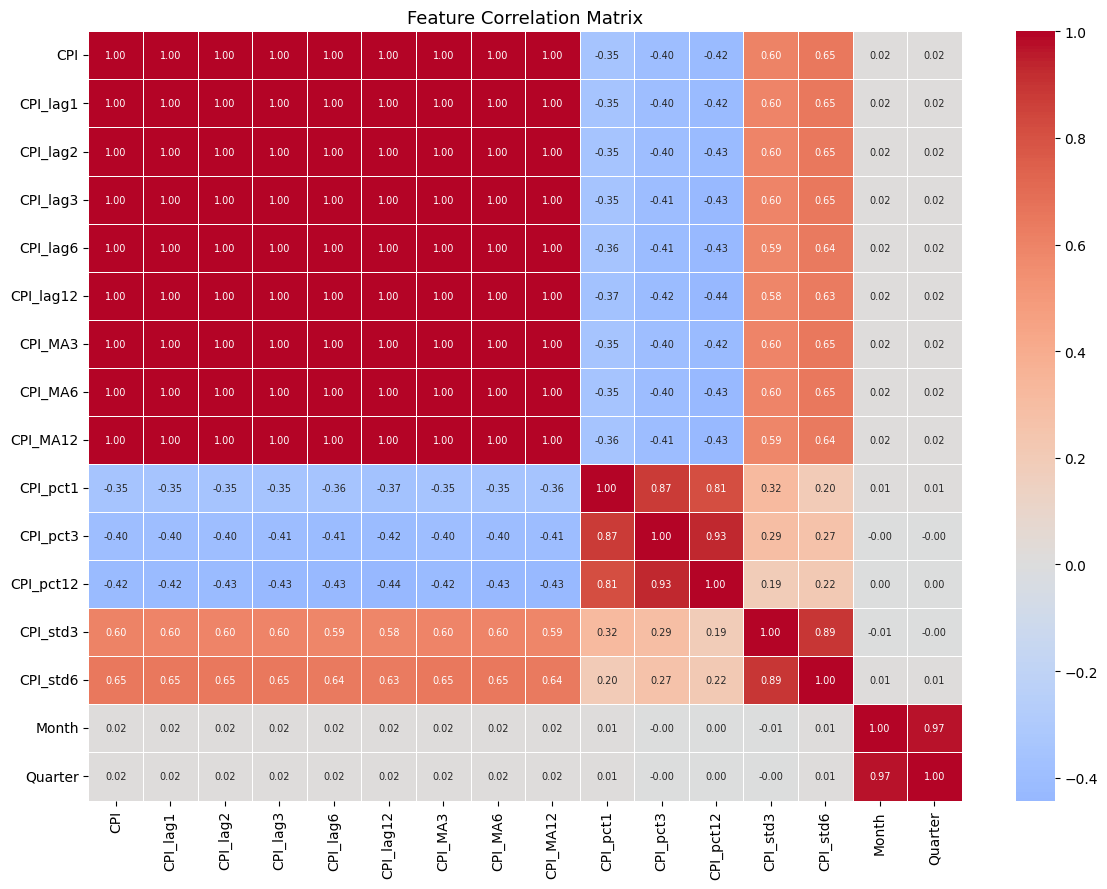

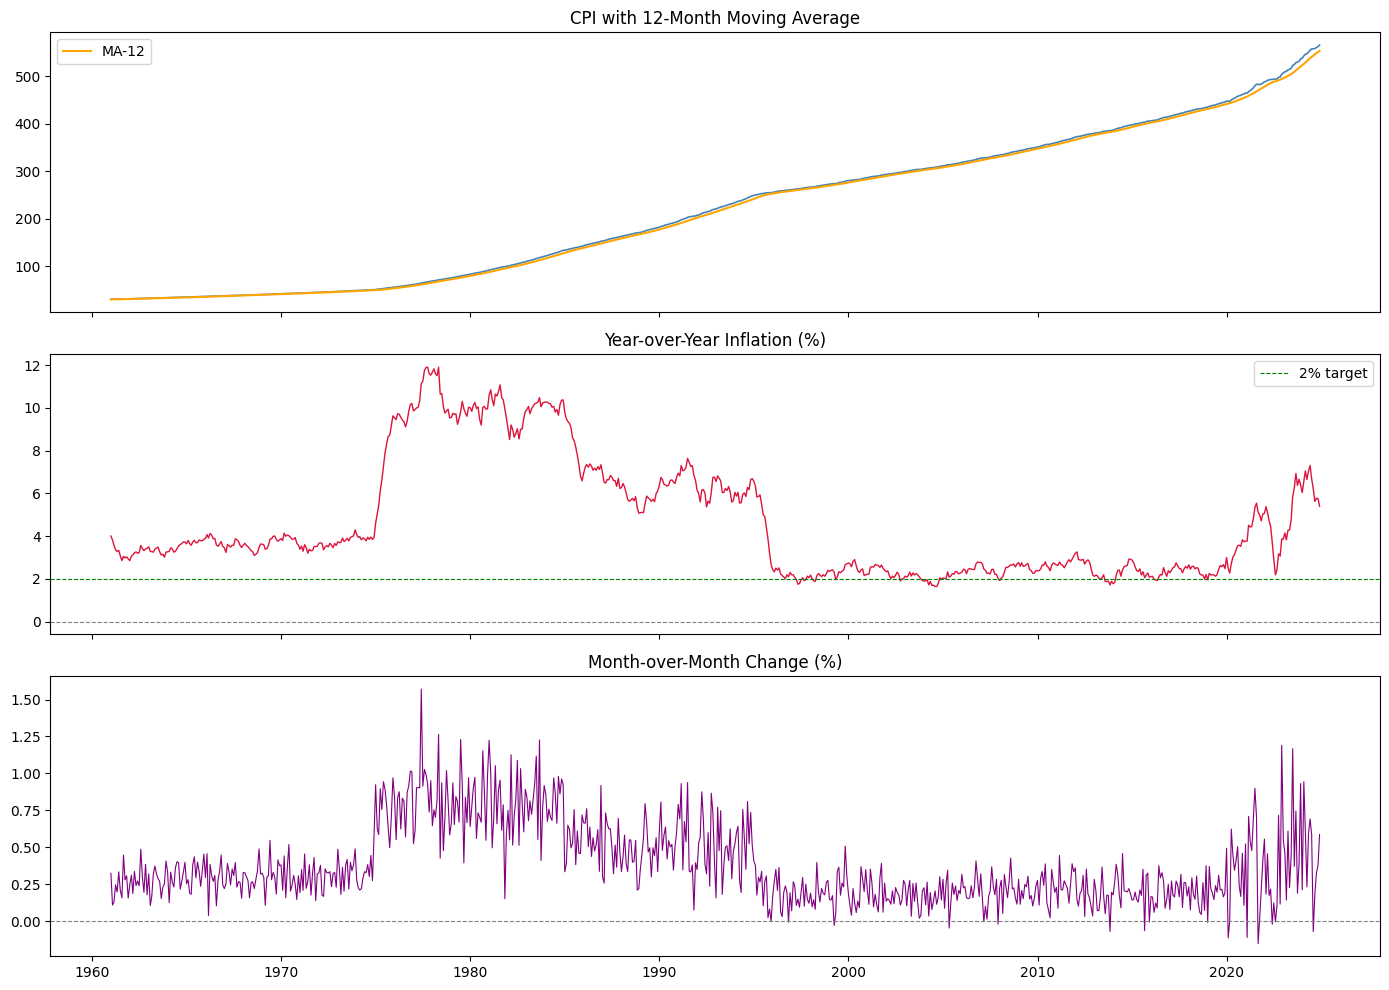

✅ Plots saved


In [1]:
# ============================================================
#  NOTEBOOK 2 — Feature Engineering & Preprocessing  (1 Cell)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib, os

os.makedirs("data",   exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

# ── Load CPI data ─────────────────────────────────────────────────────────────
df = pd.read_csv("data/cpi_data.csv", index_col=0, parse_dates=True)
print(f"Loaded: {df.shape}  |  {df.index[0].date()} → {df.index[-1].date()}")

# ── Feature Engineering ───────────────────────────────────────────────────────
def add_features(df):
    df = df.copy()
    c  = df["CPI"]

    # Lag features
    df["CPI_lag1"]  = c.shift(1)
    df["CPI_lag2"]  = c.shift(2)
    df["CPI_lag3"]  = c.shift(3)
    df["CPI_lag6"]  = c.shift(6)
    df["CPI_lag12"] = c.shift(12)

    # Rolling statistics
    df["CPI_MA3"]  = c.rolling(3).mean()
    df["CPI_MA6"]  = c.rolling(6).mean()
    df["CPI_MA12"] = c.rolling(12).mean()

    # Momentum / returns
    df["CPI_pct1"]  = c.pct_change(1)  * 100
    df["CPI_pct3"]  = c.pct_change(3)  * 100
    df["CPI_pct12"] = c.pct_change(12) * 100

    # Volatility
    df["CPI_std3"] = c.rolling(3).std()
    df["CPI_std6"] = c.rolling(6).std()

    # Calendar features
    df["Month"]   = df.index.month
    df["Quarter"] = df.index.quarter

    return df

df = add_features(df)
df.dropna(inplace=True)
print(f"After features: {df.shape}")
print("Columns:", df.columns.tolist())

FEATURE_COLS = [
    "CPI", "CPI_lag1", "CPI_lag2", "CPI_lag3",
    "CPI_lag6", "CPI_lag12",
    "CPI_MA3", "CPI_MA6", "CPI_MA12",
    "CPI_pct1", "CPI_pct3", "CPI_pct12",
    "CPI_std3", "CPI_std6",
    "Month", "Quarter"
]
TARGET_COL = "CPI"

df[FEATURE_COLS].to_csv("data/cpi_features.csv")
print("✅ Features saved → data/cpi_features.csv")

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[FEATURE_COLS].values)
y_scaled = scaler_y.fit_transform(df[[TARGET_COL]].values)

joblib.dump(scaler_X, "models/scaler_X.pkl")
joblib.dump(scaler_y, "models/scaler_y.pkl")
print("✅ Scalers saved → models/")

# ── Sequences ─────────────────────────────────────────────────────────────────
SEQ_LEN = 24    # 24 months look-back

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)
print(f"Sequences  X:{X_seq.shape}  y:{y_seq.shape}")

# ── Split 70 / 15 / 15 ───────────────────────────────────────────────────────
n         = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_seq[:train_end],        y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end],  y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],           y_seq[val_end:]

np.save("data/X_train.npy", X_train)
np.save("data/y_train.npy", y_train)
np.save("data/X_val.npy",   X_val)
np.save("data/y_val.npy",   y_val)
np.save("data/X_test.npy",  X_test)
np.save("data/y_test.npy",  y_test)

print(f"\n✅ Splits saved")
print(f"   Train : {X_train.shape}")
print(f"   Val   : {X_val.shape}")
print(f"   Test  : {X_test.shape}")

# ── Feature correlation plot ──────────────────────────────────────────────────
import seaborn as sns

corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("plots/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── CPI decomposition plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["CPI"].values,        color="steelblue", linewidth=1.2)
axes[0].plot(df.index, df["CPI_MA12"].values,   color="orange",    linewidth=1.5, label="MA-12")
axes[0].set_title("CPI with 12-Month Moving Average"); axes[0].legend()

axes[1].plot(df.index, df["CPI_pct12"].values,  color="crimson",   linewidth=1)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].axhline(2, color="green", linestyle="--", linewidth=0.8, label="2% target")
axes[1].set_title("Year-over-Year Inflation (%)"); axes[1].legend()

axes[2].plot(df.index, df["CPI_pct1"].values,   color="purple",    linewidth=0.8)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_title("Month-over-Month Change (%)")

plt.tight_layout()
plt.savefig("plots/cpi_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plots saved")